# 1. Entendimento do Negócio e Motivação do Problema

Neste trabalho, é realizada uma análise do problema de inadimplência em cartões de crédito (*credit card default*), com o objetivo de compreender os fatores associados ao não pagamento da fatura no mês seguinte.

A concessão de crédito é uma das principais atividades das instituições financeiras, sendo essencial para a geração de receita. No entanto, essa prática envolve riscos, especialmente o risco de inadimplência, que pode gerar perdas financeiras significativas e comprometer a sustentabilidade das operações.

Dessa forma, entender o perfil dos clientes inadimplentes e identificar padrões de comportamento associados ao default é fundamental para apoiar decisões estratégicas, como concessão de crédito, definição de limites e ações preventivas.

## Perguntas de Pesquisa

Neste contexto, este trabalho busca responder às seguintes questões:

- Variáveis demográficas, como idade e nível educacional, influenciam a inadimplência?
- O limite de crédito concedido está relacionado ao risco do cliente?
- O histórico recente de pagamento é um bom indicador de inadimplência futura?
- Existem diferenças relevantes entre grupos de clientes quanto ao comportamento de pagamento?

---

# 2. Descrição da Base de Dados

A base de dados utilizada neste estudo é o **Default of Credit Card Clients Dataset**, disponível no *UCI Machine Learning Repository*.

O conjunto de dados contém informações de **30.000 clientes de cartão de crédito em Taiwan**, referentes ao período de abril a setembro de 2005.

## 2.1 Visão Geral

- **Cada linha representa:** um cliente individual  
- **Total de atributos:** 24 variáveis explicativas + 1 variável alvo  
- **Tipo dos dados:** todos os atributos são numéricos  

A base contém informações demográficas, financeiras e comportamentais dos clientes.  
Uma descrição detalhada de cada variável é apresentada na seção seguinte.

---

## 2.2 Detalhamento das Variáveis

### Variável alvo

- `DEFAULT` (originalmente *default payment next month*)
  - **1:** inadimplente  
  - **0:** adimplente  

---

### Variáveis financeiras

- `LIMIT_BAL`: valor do crédito concedido (em dólares NT)  

---

### Variáveis demográficas

- `SEX`:  
  - 1 = masculino  
  - 2 = feminino  

- `EDUCATION`:  
  - 1 = pós-graduação  
  - 2 = ensino superior  
  - 3 = ensino médio  
  - 4 = outros  

- `MARRIAGE`:  
  - 1 = casado(a)  
  - 2 = solteiro(a)  
  - 3 = outros  

- `AGE`: idade em anos  

---

### Histórico de pagamento

- `PAY_0` a `PAY_6`: status de pagamento mensal  

Escala:
- **-1:** pagamento em dia  
- **1:** atraso de 1 mês  
- **2:** atraso de 2 meses  
- ...  
- **9:** atraso de 9 meses ou mais  

---

### Valores de fatura

- `BILL_AMT1` a `BILL_AMT6`: valores das faturas mensais  

---

### Valores pagos

- `PAY_AMT1` a `PAY_AMT6`: valores pagos mensalmente  

---

### Observação

Embora todas as variáveis estejam em formato numérico, algumas representam categorias (como `SEX`, `EDUCATION` e `MARRIAGE`). Portanto, devem ser interpretadas como variáveis categóricas durante a análise.

---

# 3. Preparação da Base de Dados

Durante o carregamento do dataset, foram identificadas algumas inconsistências estruturais no arquivo original:

- Presença de uma linha adicional antes do cabeçalho real  
- Nomes de colunas inicialmente incorretos  

Para corrigir esses problemas, foi utilizado o parâmetro `header=1` na leitura do arquivo, garantindo a correta identificação das colunas.

Além disso:

- A variável alvo foi renomeada para `DEFAULT`  
- Foi verificado que não há valores nulos na base  
- Não foram identificadas duplicatas relevantes  
- Todos os dados já estavam em formato numérico  

Portanto, não foi necessária uma limpeza aprofundada, apenas ajustes estruturais iniciais.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Definindo o estilo padrão dos gráficos
sns.set_theme(style="whitegrid")

# Definindo a URL direta do arquivo no repositório UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls'

print("Baixando os dados da internet, isso pode levar alguns segundos...")

# Lendo o arquivo Excel direto da internet
df = pd.read_excel(url, header=1)

# Renomeando a coluna alvo para facilitar o uso
df = df.rename(columns={'default payment next month': 'DEFAULT'})

# Exibindo o formato da base (linhas, colunas)
print(f"Formato da base: {df.shape}")

# Mostrando as primeiras linhas do dataset
display(df.head())

Baixando os dados da internet, isso pode levar alguns segundos...
Formato da base: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


# 1. Proporção de inadimplentes

Este gráfico de barras é adequado para visualizar a distribuição da variável alvo, pois permite comparar a frequência entre as categorias (inadimplente vs adimplente).

Observa-se que a maioria dos clientes não é inadimplente, indicando um leve desbalanceamento da base. Ainda assim, a quantidade de inadimplentes é significativa, justificando a análise do problema.

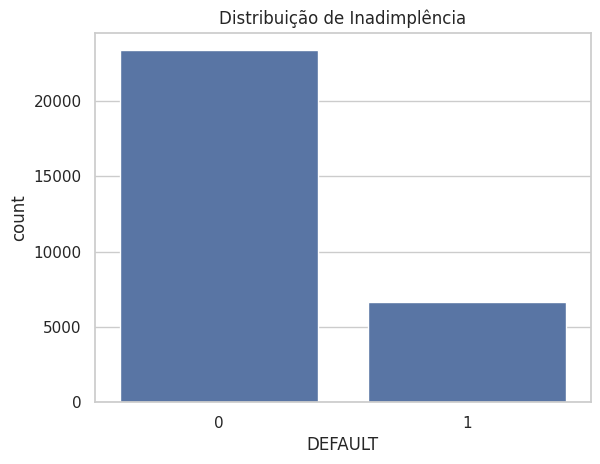

In [3]:
sns.countplot(x='DEFAULT', data=df)
plt.title('Distribuição de Inadimplência')
plt.show()

# 2. Distribuição do limite de crédito

O histograma é apropriado para analisar a distribuição de uma variável numérica contínua.

Nota-se que a maioria dos clientes possui limites mais baixos, com poucos clientes concentrando limites muito altos. Isso indica uma distribuição assimétrica.

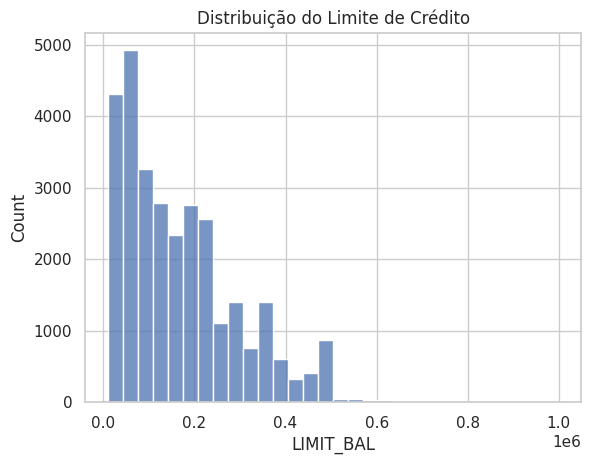

In [4]:
sns.histplot(df['LIMIT_BAL'], bins=30)
plt.title('Distribuição do Limite de Crédito')
plt.show()

# 3. Entendimento do Negócio e Motivação do Problema

O boxplot é ideal para comparar distribuições entre grupos.

Observa-se que não há uma diferença muito significativa entre os limites de crédito dos grupos, sugerindo que o limite, isoladamente, não é um forte indicador de inadimplência.

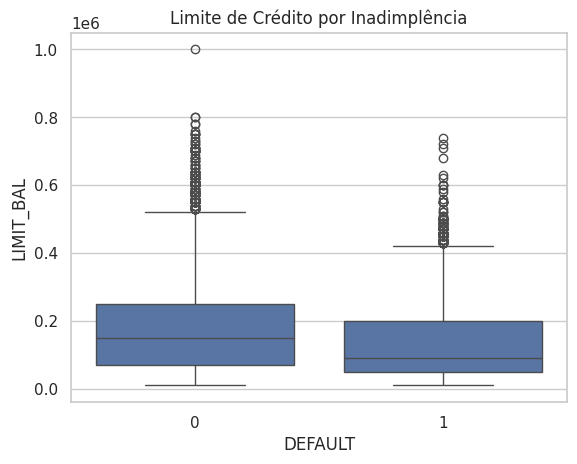

In [5]:
sns.boxplot(x='DEFAULT', y='LIMIT_BAL', data=df)
plt.title('Limite de Crédito por Inadimplência')
plt.show()

# 4. Estatísticas Descritivas

Antes de aprofundar nas relações visuais, vamos analisar as estatísticas descritivas (média, mediana, dispersão) para entender o panorama geral e as diferenças numéricas entre clientes adimplentes e inadimplentes.

In [6]:
# Resumo estatístico geral
display(df[['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']].describe())

# Comparação das médias entre os grupos (Inadimplente 1 vs Adimplente 0)
display(df.groupby('DEFAULT')[['LIMIT_BAL', 'AGE']].mean())

,LIMIT_BAL,AGE,BILL_AMT1,PAY_AMT1
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,51223.330900,5663.580500
std,129747.661567,9.217904,73635.860576,16563.280354
min,10000.000000,21.000000,-165580.000000,0.000000
25%,50000.000000,28.000000,3558.750000,1000.000000
50%,140000.000000,34.000000,22381.500000,2100.000000
75%,240000.000000,41.000000,67091.000000,5006.000000
max,1000000.000000,79.000000,964511.000000,873552.000000


,LIMIT_BAL,AGE
DEFAULT,,
0,178099.726074,35.417266
1,130109.656420,35.725738


# 5. Idade vs Inadimplência (A idade influencia o risco?)

Utilizamos um gráfico de densidade (KDE Plot) porque ele é excelente para visualizar a distribuição e a sobreposição de uma variável contínua (idade) entre duas categorias (inadimplente ou não).

**Achado:** As curvas mostram um comportamento muito similar, o que sugere que a idade, isoladamente, não é um fator determinante para a inadimplência nesta base de dados, embora haja um leve pico de inadimplência em idades mais jovens (25-30 anos).

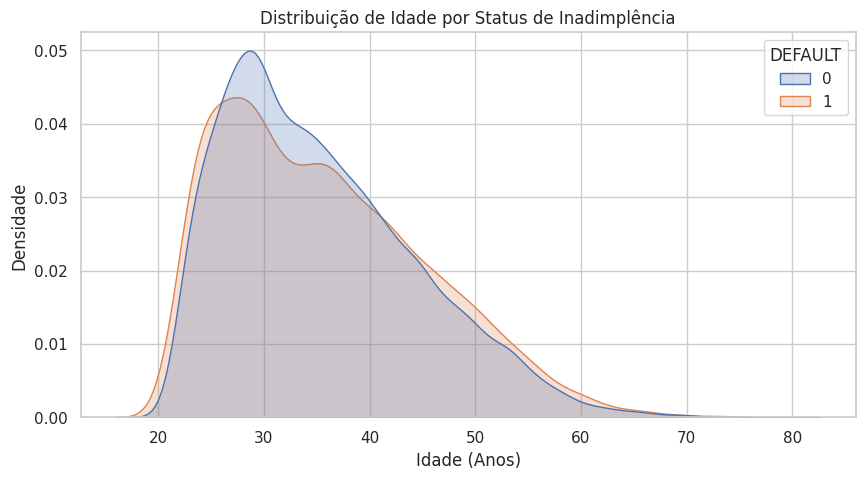

In [7]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='AGE', hue='DEFAULT', common_norm=False, fill=True)
plt.title('Distribuição de Idade por Status de Inadimplência')
plt.xlabel('Idade (Anos)')
plt.ylabel('Densidade')
plt.show()

# 6. Escolaridade vs Inadimplência (O nível educacional importa?)

Utilizamos um gráfico de barras com a taxa média de inadimplência. Esse gráfico é o mais adequado para mostrar a proporção exata de inadimplentes dentro de cada categoria de uma variável discreta.

*Lembrando: 1 = Pós-graduação, 2 = Ensino Superior, 3 = Ensino Médio, 4 = Outros.*

**Achado:** Clientes com Ensino Médio (3) ou Ensino Superior (2) tendem a ter taxas de inadimplência ligeiramente maiores do que aqueles com Pós-graduação (1) ou classificados como "Outros" (4).

/tmp/ipykernel_25467/2150935491.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='EDUCATION', y='DEFAULT', data=edu_default, palette='viridis')


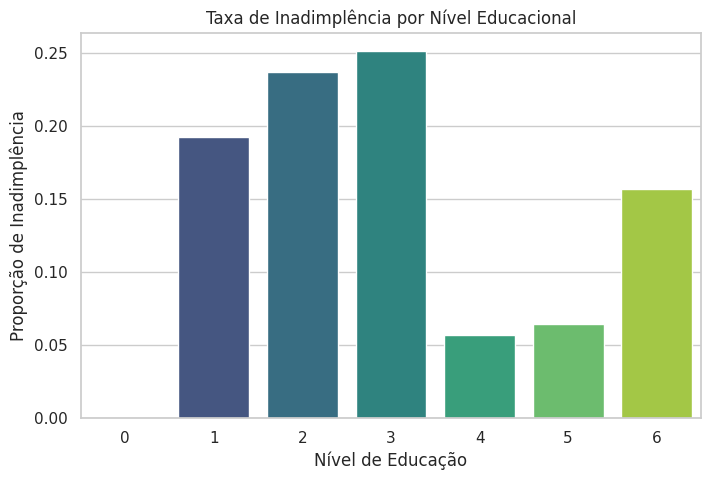

In [8]:
plt.figure(figsize=(8, 5))
# Calcula a proporção de default por nível de educação
edu_default = df.groupby('EDUCATION')['DEFAULT'].mean().reset_index()

sns.barplot(x='EDUCATION', y='DEFAULT', data=edu_default, palette='viridis')
plt.title('Taxa de Inadimplência por Nível Educacional')
plt.xlabel('Nível de Educação')
plt.ylabel('Proporção de Inadimplência')
plt.show()

# 7. Histórico de Pagamento Recente (PAY_0 é um bom indicador?)

Para comparar uma variável categórica/ordinal (status de atraso) com o alvo, o `countplot` agrupado por cor (`hue`) é ideal, pois mostra o volume real de clientes em cada situação.

*Lembrando: PAY_0 <= 0 significa pagamento em dia ou adiantado. Valores > 0 indicam meses de atraso.*

**Achado:** Esta é a relação mais forte encontrada até agora. Clientes cujo status de pagamento mais recente (`PAY_0`) apresenta atraso (valores 2, 3, etc.) têm uma probabilidade muito maior de se tornarem inadimplentes no mês seguinte. A imensa maioria dos adimplentes está concentrada nos status 0, -1 e -2.

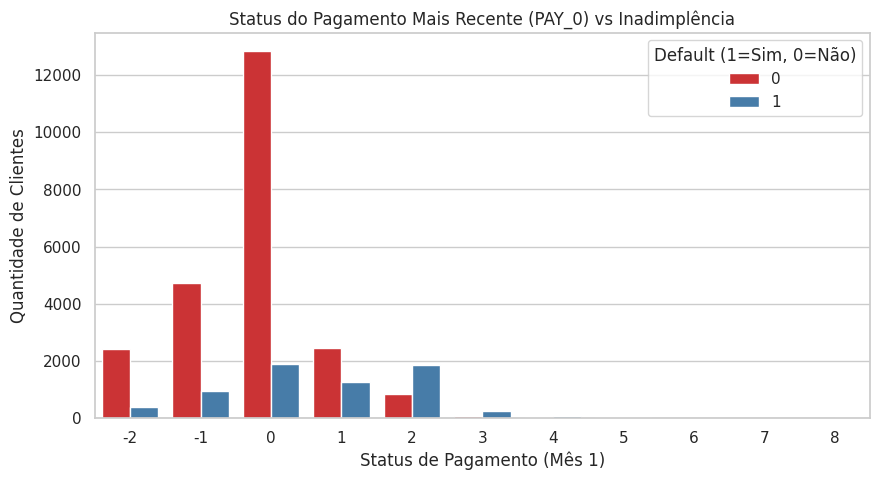

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(x='PAY_0', hue='DEFAULT', data=df, palette='Set1')
plt.title('Status do Pagamento Mais Recente (PAY_0) vs Inadimplência')
plt.xlabel('Status de Pagamento (Mês 1)')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Default (1=Sim, 0=Não)')
plt.show()

# 8. Correlação Geral (Existem associações fortes entre as variáveis financeiras?)

O mapa de calor (Heatmap) com matriz de correlação é a ferramenta definitiva para analisar a relação linear de várias variáveis numéricas simultaneamente, ajudando a identificar multicolinearidade e potenciais preditores fortes.

**Achado:** Existe uma correlação muito forte (acima de 0.8) entre os valores das faturas mensais (`BILL_AMT1` a `BILL_AMT6`), o que indica redundância (multicolinearidade). Além disso, as variáveis de status de pagamento (`PAY_0` a `PAY_6`) apresentam a maior correlação positiva com a variável alvo `DEFAULT`, confirmando a hipótese do gráfico anterior de que o histórico recente de atrasos é o melhor preditor.

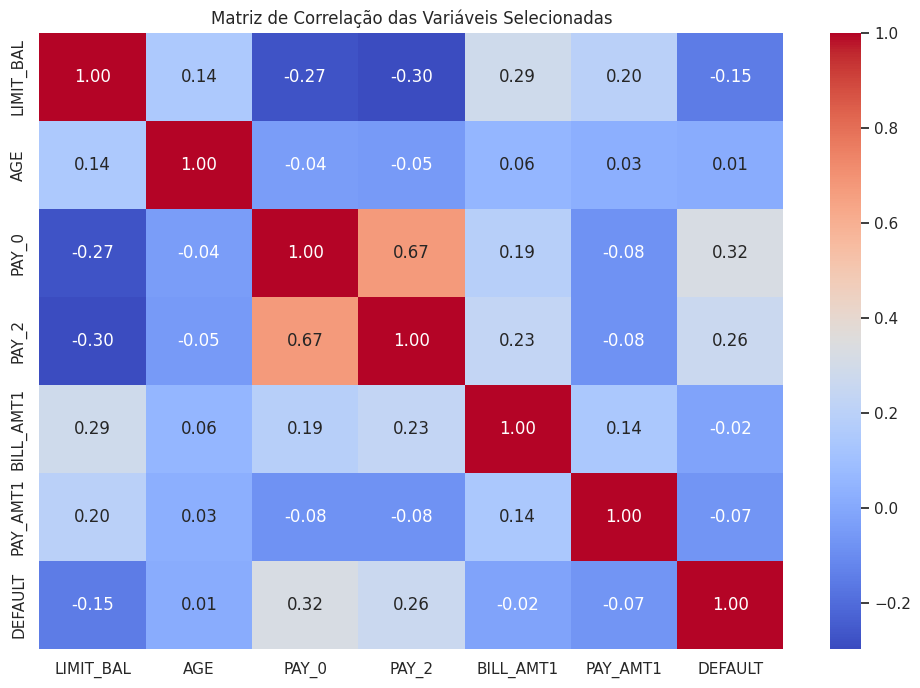

In [10]:
plt.figure(figsize=(12, 8))
# Selecionando algumas colunas chave para o mapa de calor não ficar ilegível
cols_corr = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'BILL_AMT1', 'PAY_AMT1', 'DEFAULT']
corr_matrix = df[cols_corr].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Selecionadas')
plt.show()

# 9. Síntese Crítica e Conclusões da EDA

A Análise Exploratória de Dados revelou pontos cruciais sobre o comportamento da base de clientes de cartão de crédito:

**Principais Interpretações:**
1. **Desbalanceamento:** A base apresenta cerca de 22% de inadimplentes. Embora desbalanceada, há volume suficiente para modelagem futura sem necessariamente exigir técnicas drásticas de reamostragem logo de início.
2. **Histórico é Rei:** Diferente de variáveis demográficas (como idade) ou de limite de crédito, o comportamento do usuário nos meses imediatamente anteriores (variáveis `PAY_0` a `PAY_6`) demonstrou ser o indicador mais forte de inadimplência futura. Um cliente que atrasou o pagamento no mês anterior (PAY_0 > 0) tem altíssimas chances de dar *default*.
3. **Multicolinearidade:** O valor das faturas (`BILL_AMT`) tem uma correlação linear fortíssima entre os meses. Para a etapa de modelagem (Parte 2), pode ser interessante usar técnicas de redução de dimensionalidade ou criar variáveis derivadas (ex: média do valor da fatura) para evitar ruído.

**Implicações de Negócio:**
Com base nestes achados iniciais, a instituição financeira não deve basear suas políticas de redução de limite apenas no limite atual ou na idade do cliente. Estratégias preventivas (como mensagens de aviso ou negociação antecipada) devem ser acionadas imediatamente assim que o cliente apresenta o primeiro mês de atraso (`PAY_0`), pois este é o ponto de virada crítico.

**Limitações do Dataset:**
Os dados são referentes ao ano de 2005 e específicos para o cenário de Taiwan. O comportamento de consumo e crédito pode ter mudado drasticamente com o tempo e com a cultura econômica local. Além disso, não possuímos dados sobre renda mensal do cliente, que seria uma variável explicativa valiosíssima para cruzar com o limite concedido e as dívidas ativas.